# GRPO Curriculum Results Analysis

This notebook loads GRPO training/evaluation metrics from the `runs/` folder, plots training rollout metrics, plots evaluation curves, and compares GRPO results with the SFT baseline.

Expected run folders include examples like:
- `runs/parity_sft/`
- `runs/parity_grpo_from_sft_safe/`
- `runs/parity_grpo_curriculum_boundary/`
- `runs/parity_grpo_curriculum_cheap/`


In [1]:
import json
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## Configuration

In [2]:
# If this notebook is inside formal_rl_length_generalization/experiments,
# this tries to find the repository root automatically.
NOTEBOOK_DIR = Path.cwd()

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for p in [current] + list(current.parents):
        if (p / "runs").exists() or (p / "configs").exists():
            return p
    return current

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
RUNS_DIR = REPO_ROOT / "runs"

# Change this to whichever run you want to analyze.
RUN_NAME = "parity_grpo_curriculum_boundary"
RUN_DIR = RUNS_DIR / RUN_NAME

print("Repo root:", REPO_ROOT)
print("Runs dir:", RUNS_DIR)
print("Selected run:", RUN_DIR)
print("Run exists:", RUN_DIR.exists())


Repo root: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization
Runs dir: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs
Selected run: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary
Run exists: True


## SFT baseline

In [3]:
# SFT baseline from your earlier SFT eval output.
# Update this if you rerun SFT and get a new baseline.
SFT_BASELINE = {
    "train_1_40": {
        "process": 0.9683257690431646,
        "terminal": 0.875,
        "exact": 0.775,
    },
    "ood_41_80": {
        "process": 0.5261107668939775,
        "terminal": 0.475,
        "exact": 0.0,
    },
    "ood_81_160": {
        "process": 0.520335488923764,
        "terminal": 0.4625,
        "exact": 0.0,
    },
    "ood_161_320": {
        "process": 0.4987215161762422,
        "terminal": 0.43125,
        "exact": 0.0,
    },
}

pd.DataFrame(SFT_BASELINE).T


,process,terminal,exact
train_1_40,0.968326,0.87500,0.775
ood_41_80,0.526111,0.47500,0.000
ood_81_160,0.520335,0.46250,0.000
ood_161_320,0.498722,0.43125,0.000


## Load metrics

In [4]:
def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)

def step_from_metric_file(path: Path) -> int:
    return int(path.stem.replace("metrics_step", ""))

metric_files = sorted(RUN_DIR.glob("metrics_step*.json"), key=step_from_metric_file)
train_metrics_path = RUN_DIR / "train_metrics.json"
summary_path = RUN_DIR / "summary.json"

print("Found metric files:", [p.name for p in metric_files])
print("Found train_metrics:", train_metrics_path.exists())
print("Found summary:", summary_path.exists())


Found metric files: ['metrics_step100.json', 'metrics_step200.json', 'metrics_step300.json', 'metrics_step400.json', 'metrics_step500.json']
Found train_metrics: True
Found summary: True


In [5]:
# Dense training logs from train_metrics.json
if train_metrics_path.exists():
    train_history = load_json(train_metrics_path)
    train_df = pd.DataFrame([
        {"step": rec["step"], "algorithm": rec.get("algorithm"), **rec.get("train", {})}
        for rec in train_history
    ])
else:
    train_df = pd.DataFrame()

# Eval snapshots from metrics_step*.json
eval_rows = []
snapshot_train_rows = []

for path in metric_files:
    d = load_json(path)
    step = d["step"]

    if "train" in d:
        snapshot_train_rows.append({"step": step, **d["train"]})

    for bucket, vals in d.get("eval", {}).items():
        for metric, value in vals.items():
            eval_rows.append({
                "step": step,
                "bucket": bucket,
                "metric": metric,
                "value": value,
            })

eval_df = pd.DataFrame(eval_rows)
snapshot_train_df = pd.DataFrame(snapshot_train_rows)

print("train_df shape:", train_df.shape)
print("eval_df shape:", eval_df.shape)
display(train_df.head())
display(eval_df.head())


train_df shape: (20, 23)
eval_df shape: (30, 4)


,step,algorithm,loss,policy_loss,entropy,reward,rollout_count,generated_tokens_mean,cot_tokens_mean,cot_tokens_total,cot_match_accuracy,cot_match_percent,process_match_accuracy,process_match_percent,output_match_accuracy,output_match_percent,exact_match_accuracy,exact_match_percent,curriculum_stage,train_min_len,train_max_len,generation_max_new_tokens,generation_temperature
0,25,grpo_process_terminal,-0.000000,-0.000000,0.027814,3.000000,8.0,9.5,7.5,60.0,1.000000,100.000000,1.000000,100.000000,1.0,100.0,1.0,100.0,1.0,1.0,40.0,64.0,0.25
1,50,grpo_process_terminal,-0.000000,-0.000000,0.052318,2.921052,8.0,35.5,33.5,268.0,0.960526,96.052632,0.960526,96.052632,1.0,100.0,0.5,50.0,1.0,1.0,40.0,64.0,0.25
2,75,grpo_process_terminal,-0.000000,-0.000000,0.089233,2.194444,8.0,38.0,36.0,288.0,0.847222,84.722222,0.847222,84.722222,0.5,50.0,0.0,0.0,1.0,1.0,40.0,64.0,0.25
3,100,grpo_process_terminal,-0.000000,-0.000000,0.035880,3.000000,8.0,23.0,21.0,168.0,1.000000,100.000000,1.000000,100.000000,1.0,100.0,1.0,100.0,1.0,1.0,40.0,64.0,0.25
4,125,grpo_process_terminal,0.012949,0.012949,0.097595,1.524892,8.0,39.0,37.0,296.0,0.762446,76.244589,0.762446,76.244589,0.0,0.0,0.0,0.0,2.0,35.0,44.0,56.0,0.25


,step,bucket,metric,value
0,100,train_1_40,process,0.979088
1,100,train_1_40,terminal,0.900000
2,100,train_1_40,exact,0.775000
3,100,ood_41_80,process,0.542278
4,100,ood_41_80,terminal,0.475000


## Training rollout plots

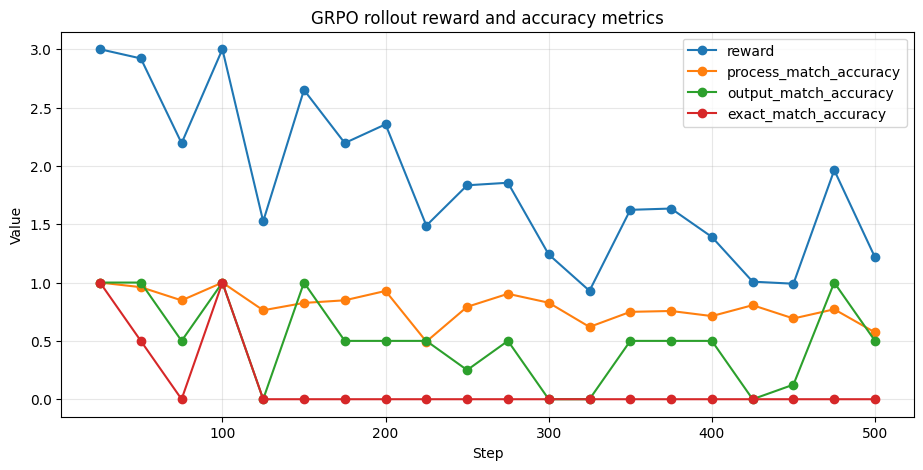

In [6]:
def plot_training_metrics(df, metrics, title, ylabel="Value"):
    if df.empty:
        print("No training metrics found.")
        return
    plt.figure(figsize=(11, 5))
    for m in metrics:
        if m in df.columns:
            plt.plot(df["step"], df[m], marker="o", label=m)
    plt.xlabel("Step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_training_metrics(
    train_df,
    ["reward", "process_match_accuracy", "output_match_accuracy", "exact_match_accuracy"],
    "GRPO rollout reward and accuracy metrics"
)


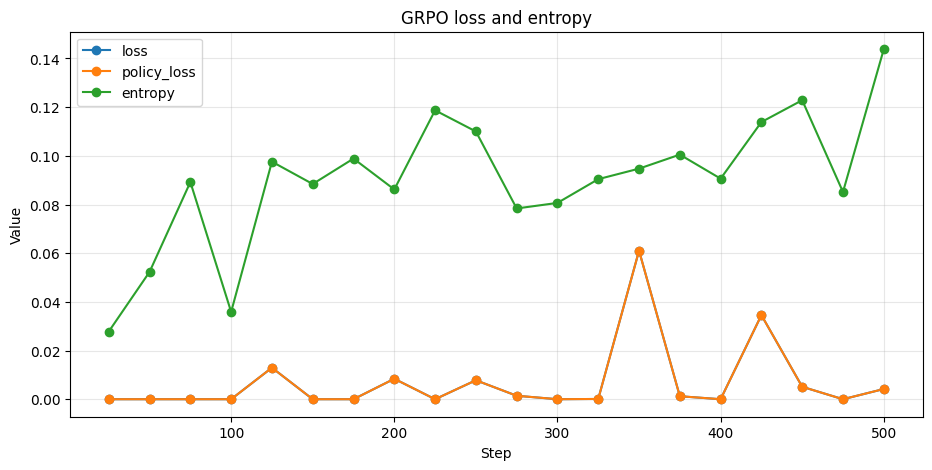

In [7]:
plot_training_metrics(
    train_df,
    ["loss", "policy_loss", "entropy"],
    "GRPO loss and entropy"
)


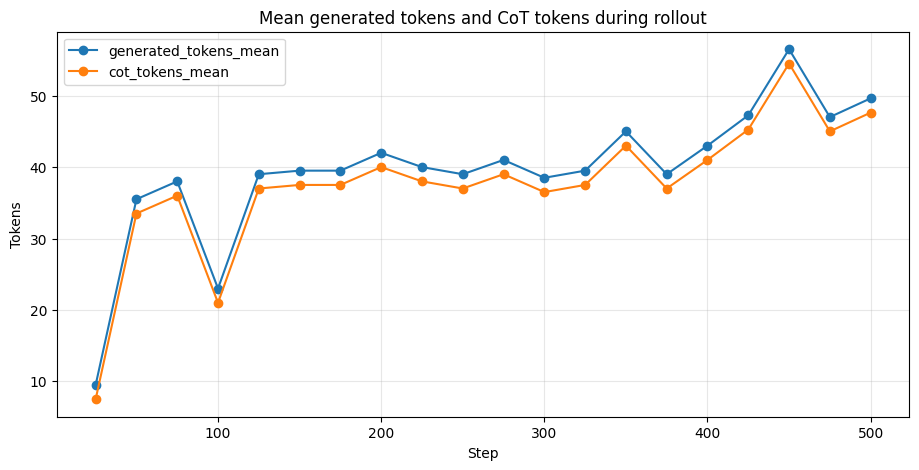

In [8]:
plot_training_metrics(
    train_df,
    ["generated_tokens_mean", "cot_tokens_mean"],
    "Mean generated tokens and CoT tokens during rollout",
    ylabel="Tokens"
)


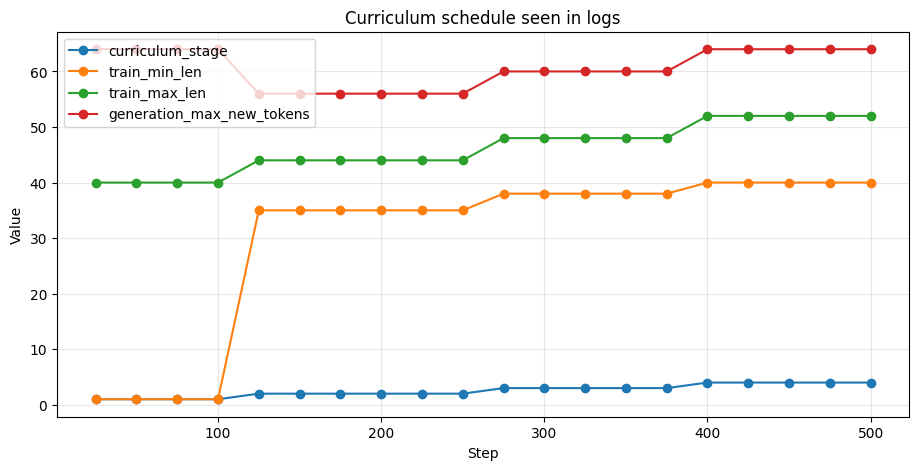

In [9]:
plot_training_metrics(
    train_df,
    ["curriculum_stage", "train_min_len", "train_max_len", "generation_max_new_tokens"],
    "Curriculum schedule seen in logs"
)


## Evaluation plots with SFT baseline

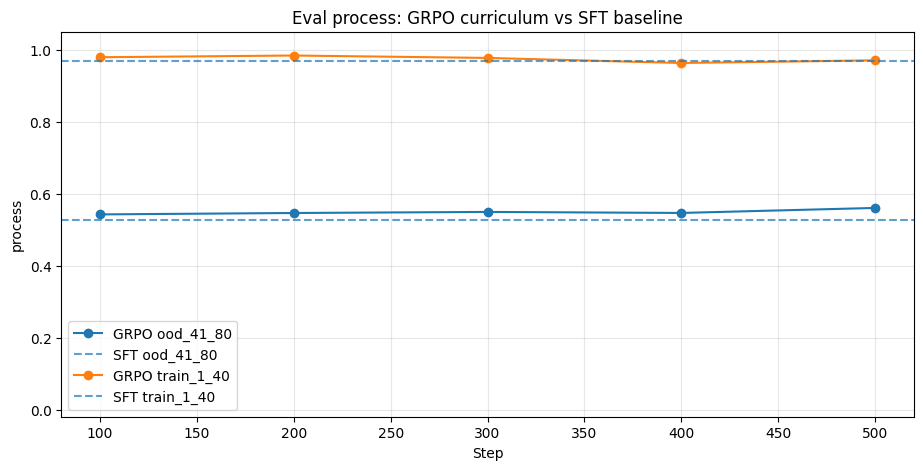

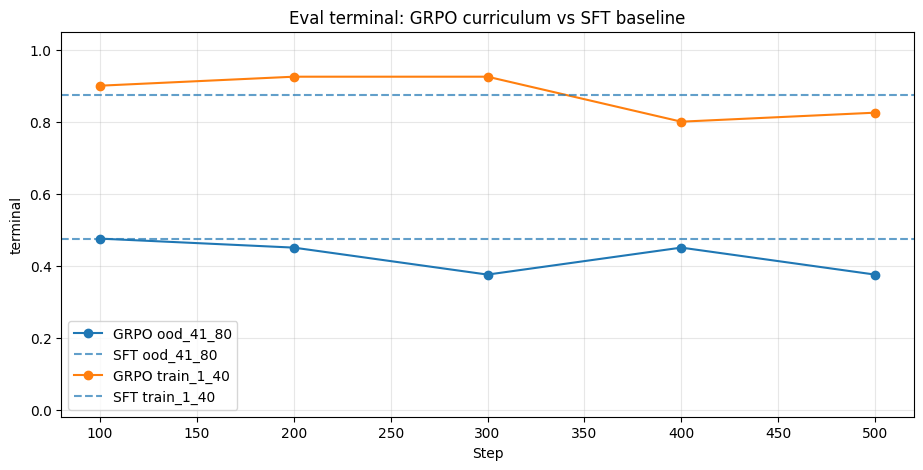

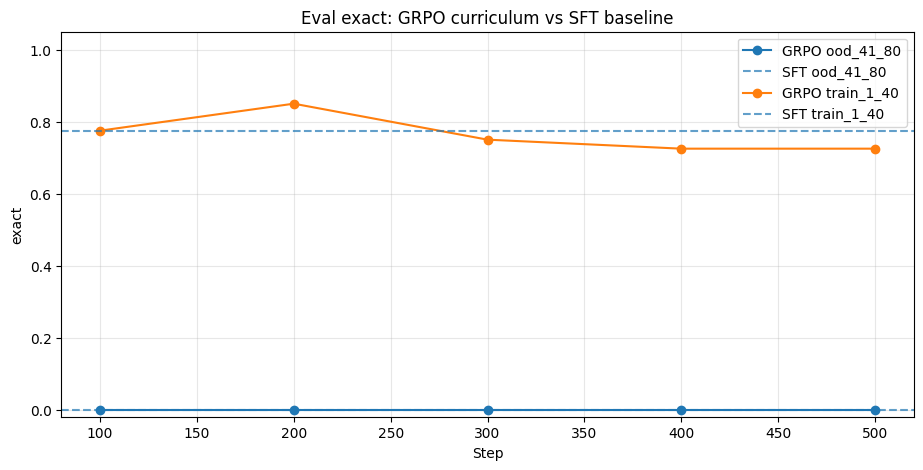

In [10]:
def plot_eval_metric(eval_df, metric, buckets=None, sft_baseline=None):
    if eval_df.empty:
        print("No eval metrics found.")
        return

    data = eval_df[eval_df["metric"] == metric].copy()
    if buckets is not None:
        data = data[data["bucket"].isin(buckets)]

    plt.figure(figsize=(11, 5))
    for bucket, g in data.groupby("bucket"):
        g = g.sort_values("step")
        plt.plot(g["step"], g["value"], marker="o", label=f"GRPO {bucket}")

        if sft_baseline and bucket in sft_baseline and metric in sft_baseline[bucket]:
            plt.axhline(
                sft_baseline[bucket][metric],
                linestyle="--",
                alpha=0.7,
                label=f"SFT {bucket}"
            )

    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.title(f"Eval {metric}: GRPO curriculum vs SFT baseline")
    plt.ylim(-0.02, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

buckets_to_plot = ["train_1_40", "ood_41_80"]
plot_eval_metric(eval_df, "process", buckets=buckets_to_plot, sft_baseline=SFT_BASELINE)
plot_eval_metric(eval_df, "terminal", buckets=buckets_to_plot, sft_baseline=SFT_BASELINE)
plot_eval_metric(eval_df, "exact", buckets=buckets_to_plot, sft_baseline=SFT_BASELINE)


## Final GRPO checkpoint vs SFT

In [11]:
def final_comparison(eval_df, sft_baseline):
    if eval_df.empty:
        return pd.DataFrame()

    final_step = int(eval_df["step"].max())
    final_eval = eval_df[eval_df["step"] == final_step]

    rows = []
    for bucket in sorted(final_eval["bucket"].unique()):
        for metric in ["process", "terminal", "exact"]:
            vals = final_eval[(final_eval["bucket"] == bucket) & (final_eval["metric"] == metric)]["value"]
            if vals.empty:
                continue
            grpo_value = float(vals.iloc[0])
            sft_value = sft_baseline.get(bucket, {}).get(metric)
            rows.append({
                "bucket": bucket,
                "metric": metric,
                "sft": sft_value,
                "grpo_final": grpo_value,
                "delta_grpo_minus_sft": None if sft_value is None else grpo_value - sft_value,
            })
    return pd.DataFrame(rows)

comparison_df = final_comparison(eval_df, SFT_BASELINE)
display(comparison_df)
display(comparison_df.pivot(index="bucket", columns="metric", values=["sft", "grpo_final", "delta_grpo_minus_sft"]))


,bucket,metric,sft,grpo_final,delta_grpo_minus_sft
0,ood_41_80,process,0.526111,0.560253,0.034142
1,ood_41_80,terminal,0.475000,0.375000,-0.100000
2,ood_41_80,exact,0.000000,0.000000,0.000000
3,train_1_40,process,0.968326,0.970457,0.002132
4,train_1_40,terminal,0.875000,0.825000,-0.050000
5,train_1_40,exact,0.775000,0.725000,-0.050000


sft                    grpo_final                    delta_grpo_minus_sft                   
metric      exact   process terminal      exact   process terminal                exact   process terminal
bucket                                                                                                    
ood_41_80   0.000  0.526111    0.475      0.000  0.560253    0.375                 0.00  0.034142    -0.10
train_1_40  0.775  0.968326    0.875      0.725  0.970457    0.825                -0.05  0.002132    -0.05

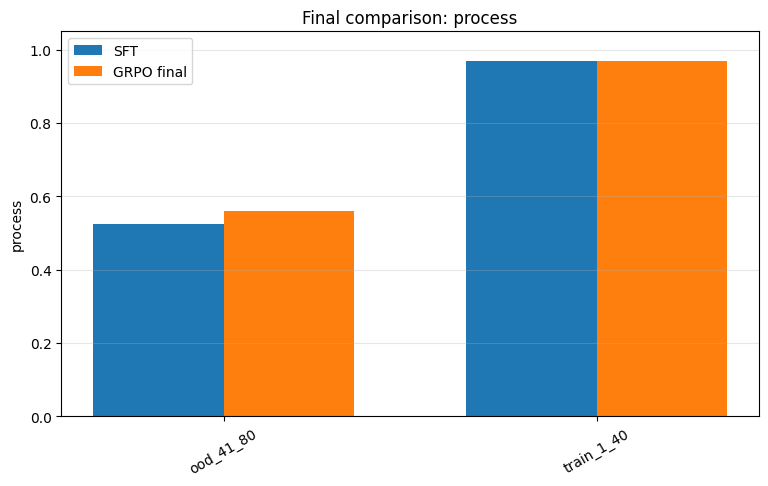

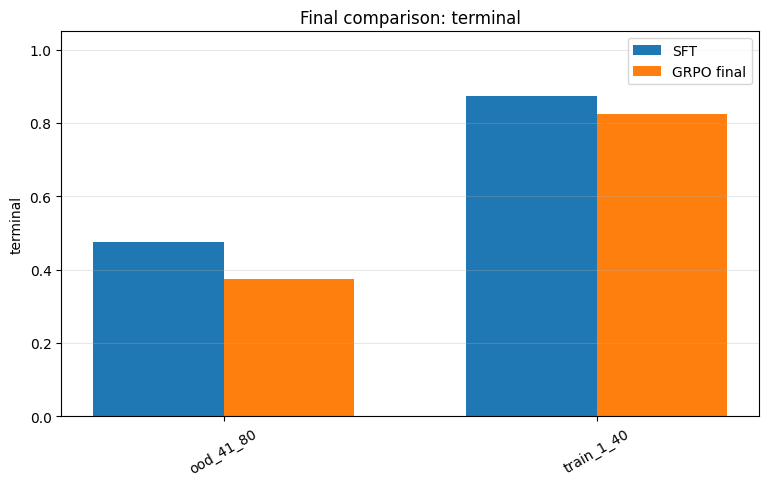

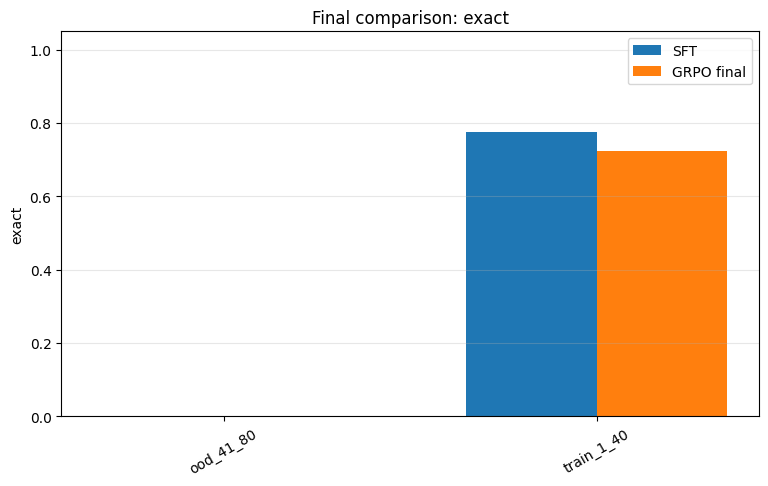

In [12]:
def plot_final_comparison(comparison_df, metric):
    df = comparison_df[comparison_df["metric"] == metric].dropna(subset=["sft"]).copy()
    if df.empty:
        print(f"No data for {metric}")
        return

    x = range(len(df))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar([i - width / 2 for i in x], df["sft"], width=width, label="SFT")
    plt.bar([i + width / 2 for i in x], df["grpo_final"], width=width, label="GRPO final")
    plt.xticks(list(x), df["bucket"], rotation=30)
    plt.ylabel(metric)
    plt.title(f"Final comparison: {metric}")
    plt.ylim(0, 1.05)
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.show()

for metric in ["process", "terminal", "exact"]:
    plot_final_comparison(comparison_df, metric)


## Best checkpoint selection

In [13]:
target_bucket = "ood_41_80"

best_by_terminal = eval_df[(eval_df["bucket"] == target_bucket) & (eval_df["metric"] == "terminal")].sort_values("value", ascending=False)
best_by_process = eval_df[(eval_df["bucket"] == target_bucket) & (eval_df["metric"] == "process")].sort_values("value", ascending=False)

print("Best checkpoints by OOD terminal:")
display(best_by_terminal)

print("Best checkpoints by OOD process:")
display(best_by_process)


Best checkpoints by OOD terminal:


,step,bucket,metric,value
4,100,ood_41_80,terminal,0.475
10,200,ood_41_80,terminal,0.450
22,400,ood_41_80,terminal,0.450
16,300,ood_41_80,terminal,0.375
28,500,ood_41_80,terminal,0.375


Best checkpoints by OOD process:


,step,bucket,metric,value
27,500,ood_41_80,process,0.560253
15,300,ood_41_80,process,0.549168
21,400,ood_41_80,process,0.546330
9,200,ood_41_80,process,0.546200
3,100,ood_41_80,process,0.542278


## Save flattened CSVs

In [14]:
out_dir = RUN_DIR / "analysis_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

if not train_df.empty:
    train_df.to_csv(out_dir / "train_metrics_flat.csv", index=False)
if not eval_df.empty:
    eval_df.to_csv(out_dir / "eval_metrics_long.csv", index=False)
if not comparison_df.empty:
    comparison_df.to_csv(out_dir / "sft_vs_grpo_comparison.csv", index=False)

print("Saved analysis outputs to:", out_dir)


Saved analysis outputs to: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs
